# NZ Grocery Price Analysis
## Understanding Why Groceries Feel Expensive in New Zealand

### Project Goal
The goal of this project is to analyze official New Zealand price index data to understand food price trends and explore why groceries feel expensive in New Zealand.

This project will explore:
- Food price inflation trends
- Differences between food categories
- Long-term changes in grocery prices

# Step 1: Import Required Libraries

In [29]:
# Importing libraries for data analysis and visualization

import pandas as pd      # Used for data manipulation and analysis
import numpy as np       # Used for numerical operations
import matplotlib.pyplot as plt   # Used for creating charts and plots
import seaborn as sns    # Used for advanced statistical visualizations

Loading the Dataset

# Step 2: Load the Dataset

In [30]:
# Loading the dataset into a pandas DataFrame

df = pd.read_csv(r"C:\Users\risha\Downloads\Nz Grocery Price Analysis\Data\selected-price-indexes-february-2024.csv")

# Displaying the first 5 rows of the dataset
df.head()

,Series_reference,Period,Data_value,STATUS,UNITS,Subject,Group,Series_title_1,Series_title_2,Series_title_3
0,CPIM.SE901,1960.01,45.923461,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN
1,CPIM.SE901,1960.02,45.498637,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN
2,CPIM.SE901,1960.03,45.116296,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN
3,CPIM.SE901,1960.04,45.158779,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN
4,CPIM.SE901,1960.05,45.286226,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN


# Step 3: Explore Dataset Structure

In [31]:
# Check number of rows and columns in the dataset
df.shape

(52667, 10)

In [32]:
# View column names in the dataset
df.columns

Index(['Series_reference', 'Period', 'Data_value', 'STATUS', 'UNITS',
       'Subject', 'Group', 'Series_title_1', 'Series_title_2',
       'Series_title_3'],
      dtype='object')

In [33]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52667 entries, 0 to 52666
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Series_reference  52667 non-null  object 
 1   Period            52667 non-null  float64
 2   Data_value        52576 non-null  float64
 3   STATUS            52667 non-null  object 
 4   UNITS             52667 non-null  object 
 5   Subject           52667 non-null  object 
 6   Group             52667 non-null  object 
 7   Series_title_1    52667 non-null  object 
 8   Series_title_2    1455 non-null   object 
 9   Series_title_3    1455 non-null   object 
dtypes: float64(2), object(8)
memory usage: 4.0+ MB


In [34]:
# Generate summary statistics for numerical columns
df.describe()

,Period,Data_value
count,52667.000000,52576.000000
mean,2012.667339,367.798469
std,9.446606,481.020553
min,1960.010000,-2.000000
25%,2009.080000,3.330000
50%,2014.100000,8.690000
75%,2019.060000,870.604253
max,2024.020000,2488.000000


In [35]:
# Explore the different categories and product names in the dataset
# This helps us understand the structure of the data and identify food-related categories
df["Series_title_1"].unique()

array(['Food', 'Fruit and vegetables', 'Fruit', 'Vegetables',
       'Meat, poultry and fish', 'Meat and poultry',
       'Beef and veal (fresh, chilled or frozen)',
       'Pork (fresh, chilled or frozen)',
       'Mutton, lamb and hogget (fresh, chilled or frozen)',
       'Poultry (fresh, chilled or frozen)',
       'Preserved, prepared and processed meat', 'Fish and other seafood',
       'Grocery food', 'Bread and cereals', 'Bread', 'Cakes and biscuits',
       'Breakfast cereals', 'Pasta products', 'Pastry-cook products',
       'Other cereal products', 'Milk, cheese and eggs', 'Fresh milk',
       'Preserved milk', 'Yoghurt (fresh, frozen)', 'Cheese',
       'Other milk products', 'Eggs', 'Oils and fats',
       'Food additives and condiments', 'Confectionery, nuts and snacks',
       'Other grocery food', 'Non-alcoholic beverages',
       'Coffee, tea and other hot drinks',
       'Soft drinks, waters and juices',
       'Restaurant meals and ready-to-eat food', 'Restaurant mea

In [36]:
# Count the number of occurrences for each category in Series_title_1
# This helps us understand how the data is distributed across different categories
# and identify which categories are relevant for our analysis
df["Series_title_1"].value_counts()

Series_title_1
Seasonally adjusted                              4344
Food                                             2297
Meat, poultry and fish                            698
Poultry (fresh, chilled or frozen)                542
Restaurant meals                                  542
                                                 ... 
Domestic accommodation services                    81
Overseas accommodation prepaid in New Zealand      81
Tea bags, flavoured or herbal, box of 25           77
Fresh herbs, packaged, chilled                     77
Olives, jar, 400g                                  77
Name: count, Length: 212, dtype: int64

In [37]:
# Filter the dataset to include only rows where the main category is "Food"
# This ensures we focus only on food-related price data
food_df = df[df["Series_title_1"] == "Food"]

# Display first few rows of the filtered dataset
food_df.head()

,Series_reference,Period,Data_value,STATUS,UNITS,Subject,Group,Series_title_1,Series_title_2,Series_title_3
0,CPIM.SE901,1960.01,45.923461,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN
1,CPIM.SE901,1960.02,45.498637,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN
2,CPIM.SE901,1960.03,45.116296,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN
3,CPIM.SE901,1960.04,45.158779,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN
4,CPIM.SE901,1960.05,45.286226,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN


In [38]:
# Filter the dataset to include only rows where the main category is "Food"
# .copy() avoids warning issues later
food_df = df[df["Series_title_1"] == "Food"].copy()

food_df.head()

,Series_reference,Period,Data_value,STATUS,UNITS,Subject,Group,Series_title_1,Series_title_2,Series_title_3
0,CPIM.SE901,1960.01,45.923461,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN
1,CPIM.SE901,1960.02,45.498637,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN
2,CPIM.SE901,1960.03,45.116296,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN
3,CPIM.SE901,1960.04,45.158779,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN
4,CPIM.SE901,1960.05,45.286226,FINAL,Index,Consumers Price Index - CPI,Food Price Index Level 1 Groups for New Zealan...,Food,NaN,NaN


In [39]:
# Convert Period column to string
food_df["Period"] = food_df["Period"].astype(str)

# Extract year and month
food_df["Year"] = food_df["Period"].str[:4]
food_df["Month"] = food_df["Period"].str[5:]

# Create proper date column
food_df["Date"] = pd.to_datetime(food_df["Year"] + "-" + food_df["Month"])

# Check result
food_df[["Period", "Date"]].head()

,Period,Date
0,1960.01,1960-01-01
1,1960.02,1960-02-01
2,1960.03,1960-03-01
3,1960.04,1960-04-01
4,1960.05,1960-05-01


### Cleaning the dataset by removing missing values and sorting by date
### This ensures the time-series plot is accurate and properly ordered

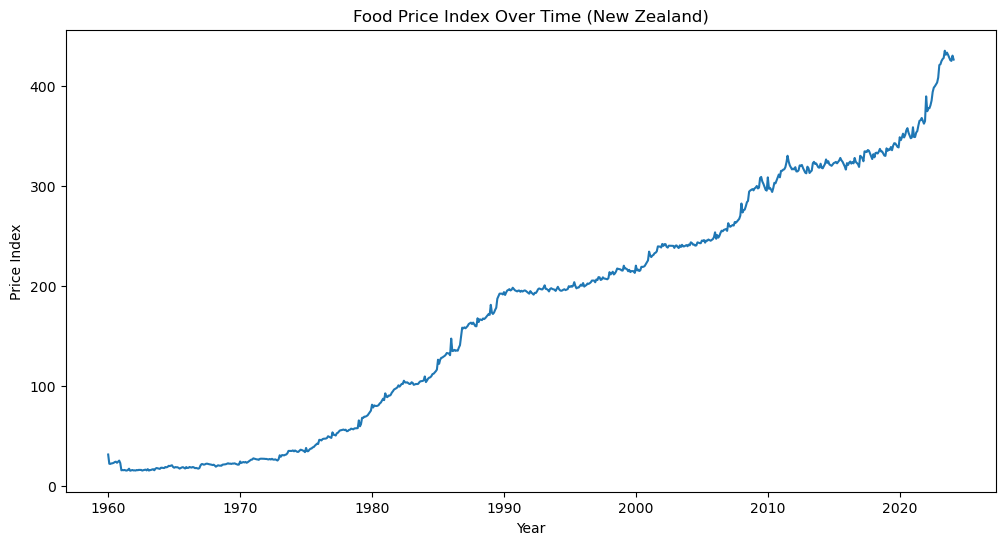

In [40]:
# Clean data
food_clean = food_df.dropna(subset=["Data_value"])

# Sort by date
food_clean = food_clean.sort_values("Date")

# Group by Date and take average price index
food_grouped = food_clean.groupby("Date")["Data_value"].mean().reset_index()

# Plot clean graph
plt.figure(figsize=(12,6))

plt.plot(food_grouped["Date"], food_grouped["Data_value"])

plt.title("Food Price Index Over Time (New Zealand)")
plt.xlabel("Year")
plt.ylabel("Price Index")

plt.show()

## Insight 1: Long-Term Food Price Increase in New Zealand

The food price index shows a clear upward trend over time, indicating that food prices in New Zealand have consistently increased.

The most significant increase occurs after 2020, where the slope of the graph becomes much steeper. This suggests that recent years have experienced higher food inflation compared to previous decades.

This trend supports the idea that groceries feel more expensive today due to rapid price increases in recent years.

### Focus on recent years to analyze modern grocery price trends

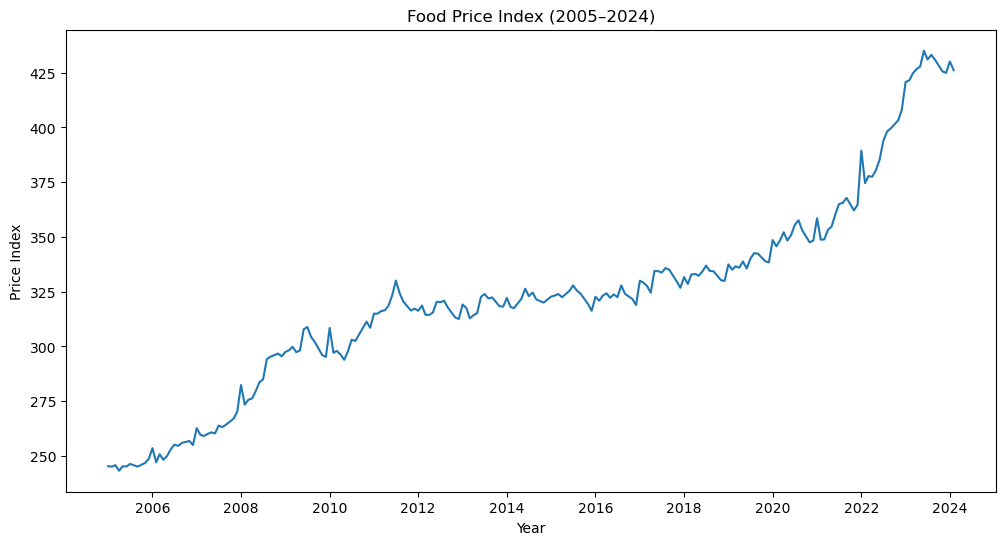

In [41]:
# Filter recent data (2005 onwards)
recent_data = food_grouped[food_grouped["Date"] >= "2005-01-01"]

# Plot recent trend
plt.figure(figsize=(12,6))

plt.plot(recent_data["Date"], recent_data["Data_value"])

plt.title("Food Price Index (2005–2024)")
plt.xlabel("Year")
plt.ylabel("Price Index")

plt.show()

## Insight 2: Rapid Increase in Food Prices After 2020

From the graph, food prices remained relatively stable between 2012 and 2019, with gradual growth.

However, starting from 2020, there is a sharp and rapid increase in the food price index. This suggests that recent inflation has significantly impacted grocery prices.

The steep rise between 2021 and 2023 indicates a period of high food inflation, which explains why consumers perceive groceries as becoming more expensive in recent years.

### Analyze price trends for different food categories to identify which contributes most to inflation

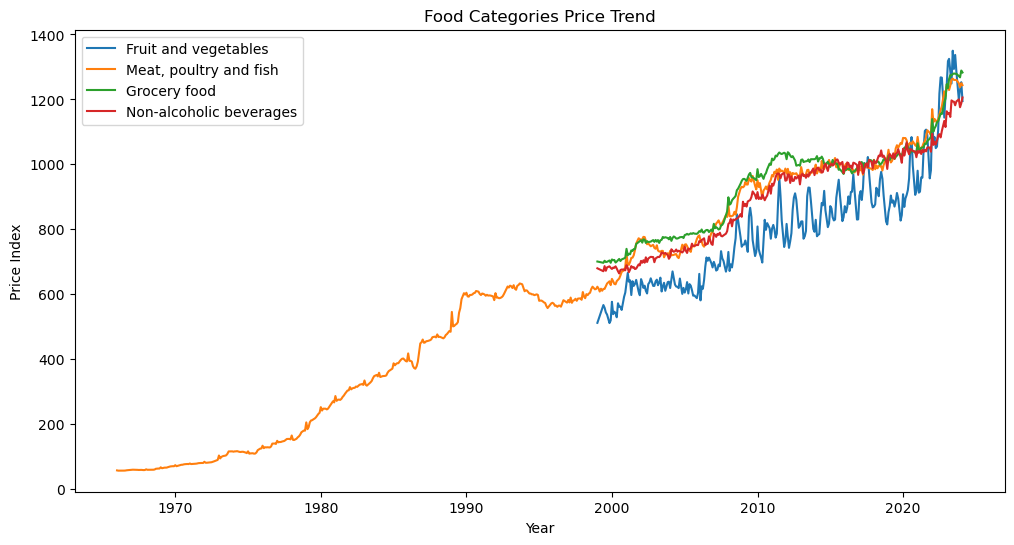

In [42]:
# Filter main food categories
categories = [
    "Fruit and vegetables",
    "Meat, poultry and fish",
    "Grocery food",
    "Non-alcoholic beverages"
]

category_df = df[df["Series_title_1"].isin(categories)].copy()

# Clean data
category_df = category_df.dropna(subset=["Data_value"])

# Convert Period to string
category_df["Period"] = category_df["Period"].astype(str)

# Extract year and month
category_df["Year"] = category_df["Period"].str[:4]
category_df["Month"] = category_df["Period"].str[5:]

# Create date column
category_df["Date"] = pd.to_datetime(category_df["Year"] + "-" + category_df["Month"])

# Group data
category_grouped = category_df.groupby(["Date", "Series_title_1"])["Data_value"].mean().reset_index()

# Plot
plt.figure(figsize=(12,6))

for category in categories:
    temp = category_grouped[category_grouped["Series_title_1"] == category]
    plt.plot(temp["Date"], temp["Data_value"], label=category)

plt.title("Food Categories Price Trend")
plt.xlabel("Year")
plt.ylabel("Price Index")
plt.legend()

plt.show()

## Insight 3: Category-Level Drivers of Grocery Price Increases

Different food categories show distinct price patterns over time.

- Fruit and vegetables are highly volatile, with frequent spikes and drops. This suggests seasonal effects and supply-related issues.
- Meat, poultry and fish show a strong long-term upward trend, indicating consistent price increases over decades.
- Grocery food exhibits steady growth, suggesting that packaged food prices are gradually rising.
- Non-alcoholic beverages show moderate and stable growth.

After 2020, all categories experience noticeable increases, indicating widespread food inflation rather than a single category driving price increases.

This suggests that the rise in grocery prices is a combined effect of multiple food categories rather than a single source.

### Calculate percentage increase in food prices from 2005 onwards
### This focuses on modern trends and avoids misleading long-term inflation effects

In [43]:
# Filter recent data (2005 onwards)
recent_category = category_grouped[category_grouped["Date"] >= "2005-01-01"]

# Get earliest and latest values (from 2005)
earliest = recent_category.groupby("Series_title_1").first()
latest = recent_category.groupby("Series_title_1").last()

# Calculate percentage growth
growth = ((latest["Data_value"] - earliest["Data_value"]) / earliest["Data_value"]) * 100

growth

Series_title_1
Fruit and vegetables       97.452435
Grocery food               63.978749
Meat, poultry and fish     65.264942
Non-alcoholic beverages    61.487525
Name: Data_value, dtype: float64

## Insight 4: Percentage Increase in Food Categories (2005–2024)

From 2005 to 2024, all major food categories have experienced significant price increases.

- Fruit and vegetables increased by approximately 97%, making it the fastest-growing category.
- Meat, poultry and fish increased by around 65%.
- Grocery food increased by about 64%.
- Non-alcoholic beverages increased by around 61%.

This indicates that grocery price inflation is broad-based across all food categories. However, fruit and vegetables contribute most to price volatility and noticeable cost increases.

The high increase in essential food categories explains why consumers perceive groceries as increasingly expensive in recent years.

In [44]:
# Check for missing values in each column
# Most columns have no missing values, indicating clean data
# Series_title_2 and Series_title_3 have missing values because we are working with top-level category data
food_df.isnull().sum()

Series_reference       0
Period                 0
Data_value             0
STATUS                 0
UNITS                  0
Subject                0
Group                  0
Series_title_1         0
Series_title_2      2297
Series_title_3      2297
Year                   0
Month                  0
Date                   0
dtype: int64

In [45]:
# Check for duplicate rows in the dataset
# No duplicates found, indicating data consistency
food_df.duplicated().sum()

0

### Visualize percentage growth across food categories to compare which category increased the most

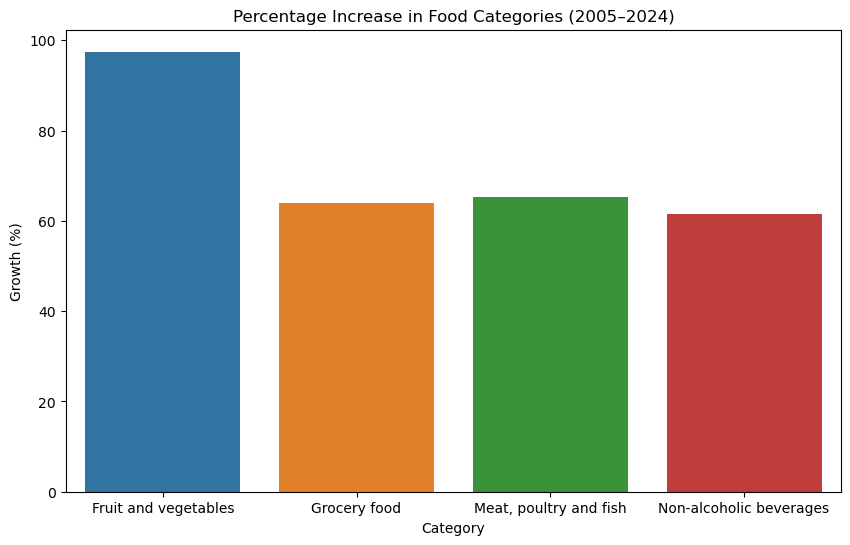

In [46]:
# Create a bar chart for percentage growth

import seaborn as sns

# Reset index for plotting
growth_df = growth.reset_index()

plt.figure(figsize=(10,6))

sns.barplot(x="Series_title_1", y="Data_value", data=growth_df)

plt.title("Percentage Increase in Food Categories (2005–2024)")
plt.xlabel("Category")
plt.ylabel("Growth (%)")

plt.show()

## Insight 5: Category Comparison Using Bar Chart

The bar chart clearly shows differences in price increases across food categories.

- Fruit and vegetables experienced the highest growth (~97%), making them the biggest contributor to grocery price increases.
- Meat, poultry and fish, and grocery food showed moderate increases (~64–65%).
- Non-alcoholic beverages had the lowest increase (~61%), but still contributed to overall inflation.

This visualization highlights that while all categories are affected, fresh produce plays a major role in rising grocery costs.

### Calculate volatility of each category using standard deviation of percentage change
### This helps identify which categories have unstable or fluctuating prices

In [47]:
# Calculate volatility (standard deviation of price changes)

# Sort data first
category_grouped = category_grouped.sort_values("Date")

# Calculate month-to-month percentage change
category_grouped["pct_change"] = category_grouped.groupby("Series_title_1")["Data_value"].pct_change()

# Calculate volatility (standard deviation)
volatility = category_grouped.groupby("Series_title_1")["pct_change"].std()

volatility

Series_title_1
Fruit and vegetables       0.049788
Grocery food               0.010887
Meat, poultry and fish     0.022591
Non-alcoholic beverages    0.015420
Name: pct_change, dtype: float64

## Insight 6: Price Volatility Across Food Categories

Volatility analysis shows that fruit and vegetables have the highest price fluctuations over time, with a standard deviation of approximately 0.05.

This indicates that prices for fresh produce are highly unstable compared to other categories.

In contrast:
- Grocery food has the lowest volatility, showing stable price increases.
- Meat and beverages show moderate stability.

The combination of high growth and high volatility in fruit and vegetables makes them a key driver of both rising and unpredictable grocery costs in New Zealand.

## Final Analytical Summary

The analysis of New Zealand food prices reveals several key findings:

1. Food prices have steadily increased over time, with a sharp acceleration after 2020.
2. All major food categories have experienced significant growth, with increases exceeding 60% since 2005.
3. Fruit and vegetables have the highest growth (~97%) and the highest volatility, making them the most impactful category.
4. Grocery food and meat show stable but consistent long-term increases.
5. The rise in grocery prices is not driven by a single category but is a combined effect of widespread inflation across food categories.

Overall, the increasing and volatile nature of food prices explains why consumers perceive groceries as becoming significantly more expensive in New Zealand.

### Export the cleaned dataset so it can be imported into PostgreSQL for SQL analysis

In [48]:
# Export cleaned category-level dataset for SQL analysis
category_grouped.to_csv(
    r"C:\Users\risha\Downloads\Nz Grocery Price Analysis\Data\category_grouped.csv",
    index=False
)

# Check first 5 rows
category_grouped.head()

,Date,Series_title_1,Data_value,pct_change
0,1966-01-01,"Meat, poultry and fish",57.611752,NaN
1,1966-02-01,"Meat, poultry and fish",56.839181,-0.013410
2,1966-03-01,"Meat, poultry and fish",56.839181,0.000000
3,1966-04-01,"Meat, poultry and fish",56.728814,-0.001942
4,1966-05-01,"Meat, poultry and fish",56.618446,-0.001946


In [49]:
category_grouped.columns

Index(['Date', 'Series_title_1', 'Data_value', 'pct_change'], dtype='object')